Random Forest sauvegardé dans ../model/churn_rf.pkl


c:\Users\USER\Downloads\ml-churn-prediction\venv\lib\site-packages\xgboost\training.py:199: UserWarning: [08:51:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost sauvegardé dans ../model/churn_xgb.pkl
---- Random Forest ----
Accuracy : 0.7853589196872779
Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



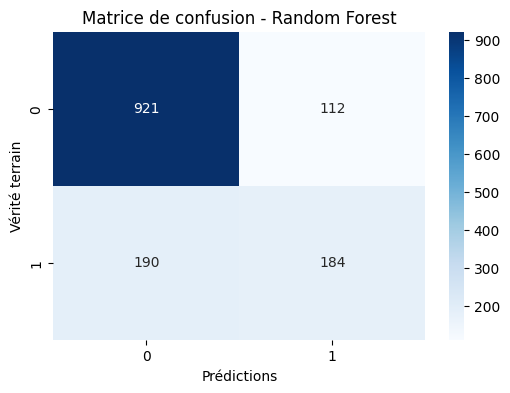

---- XGBoost ----
Accuracy : 0.7839374555792467
Classification Report :
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



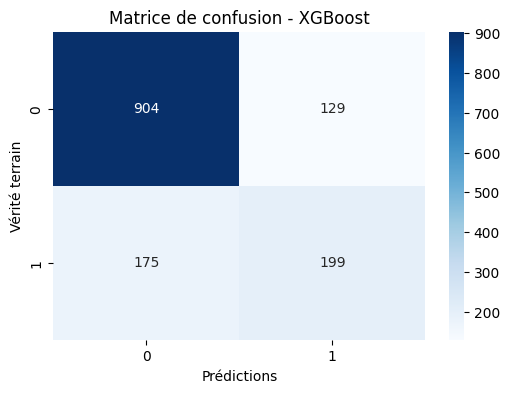

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [12]:
# Importer les fonctions
from preprocess import load_data, preprocess_data, split_data
from train_model import train_random_forest, train_xgboost
from evaluate import evaluate_model

# Prétraitement
df = load_data("../data/clean_telco.csv")
X, y = preprocess_data(df)
X_train, X_test, y_train, y_test = split_data(X, y)

# Entraînement
rf_model = train_random_forest(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

# Évaluation
evaluate_model(rf_model, X_test, y_test, model_name="Random Forest")
evaluate_model(xgb_model, X_test, y_test, model_name="XGBoost")


In [13]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Liste des colonnes catégorielles
cat_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
            "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
            "PaperlessBilling", "PaymentMethod"]

# Créer et sauvegarder un encoder par colonne
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    joblib.dump(le, f"../model/le_{col}.pkl")


In [14]:
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
scaler.fit(X_train[num_cols])
joblib.dump(scaler, "../model/scaler.pkl")


['../model/scaler.pkl']